In [2]:
# ================================================================
#  NASA C-MAPSS — AŞAMA 3
#  Physics-Informed Loss + BiLSTM+Attention + ClusterNorm
#  + Transformer → GRU Meta
#
#  Aşama 2B'den TEK fark: Physics-Informed Loss
#
#  Neden Physics Loss?
#    Gerçek hayatta turbofan motoru iyileşemez.
#    RUL monoton azalmalı: döngü t+1'de tahmin ≤ döngü t'deki tahmin
#    Ama model bazen "motor iyileşti" der → fizik yasasını çiğner.
#
#    Çözüm: Monotonluk cezası
#      Aynı motor, ardışık pencereler için:
#      pred[t+1] > pred[t] → bu fiziksel olarak yanlış → cezalandır
#
#    Loss = HuberLoss(pred, true_RUL)
#         + λ × mean(relu(pred[t+1] - pred[t]))
#
#    λ (lambda): ceza ağırlığı — 0.1 ile başla
#      Çok büyük → model her şeyi azaltmaya çalışır, RMSE artar
#      Çok küçük → etkisiz
#
#  Beklenti:
#    Tahmin salınımları azalır (Gerçek vs Tahmin grafiği daha düzgün)
#    FD002/FD004 gibi çok koşullu subsetlerde iyileşme beklenir
#    RMSE %1-3 iyileşme
#
#  Aşama 2B ile karşılaştırma için A2B sonuçları saklanır.
# ================================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time, warnings, os, zipfile, copy, json
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_RUL = 125
SEQ_LEN = 30

print(f"Cihaz : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU   : {torch.cuda.get_device_name(0)}")

from google.colab import drive
drive.mount('/content/drive')

A2B_CKPT_ROOT = '/content/drive/MyDrive/cmapss_checkpoints/asama2b'
A3_CKPT_ROOT  = '/content/drive/MyDrive/cmapss_checkpoints/asama3'
SAVE_ROOT     = '/content/drive/MyDrive/cmapss_asama3'
os.makedirs(A3_CKPT_ROOT, exist_ok=True)
os.makedirs(SAVE_ROOT,    exist_ok=True)

# Aşama 2B en iyi sonuçları (karşılaştırma için)
A2B_BEST = {
    'FD001': {'best_rmse': 12.762, 'best_r2': 0.8157, 'model': 'GRU Meta'},
    'FD002': {'best_rmse': 15.420, 'best_r2': 0.7525, 'model': 'Basit Ensemble'},
    'FD003': {'best_rmse': 10.346, 'best_r2': 0.8486, 'model': 'Basit Ensemble'},
    'FD004': {'best_rmse': 13.877, 'best_r2': 0.7419, 'model': 'Basit Ensemble'},
}

Cihaz : cuda
GPU   : NVIDIA L4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 1 — Physics-Informed Loss                ║
# ╚══════════════════════════════════════════════════╝

class PhysicsInformedLoss(nn.Module):
    """
    Fizik kısıtlı kayıp fonksiyonu.

    Temel fikir:
      Turbofan motoru bozulur, iyileşmez.
      RUL monoton azalmalı: pred[t+1] ≤ pred[t]
      (aynı motor, ardışık döngüler)

    Uygulama:
      Mini-batch içinde ardışık örnekler aynı motora ait olmayabilir.
      Bu yüzden basit yaklaşım kullanıyoruz:
        Tahminlerin negatif gradyanını cezalandır —
        yani tahmin aniden arttıysa cezalandır.

      monoton_ceza = mean(relu(pred[i+1] - pred[i]))
                   ← sadece artışları cezalandır, azalışları değil

    Toplam loss:
      L = HuberLoss(pred, true) + λ * monoton_ceza

    λ seçimi:
      0.05 → hafif kısıt (önce bunu dene)
      0.10 → orta kısıt
      0.20 → güçlü kısıt (RMSE artabilir)
    """
    def __init__(self, lambda_phys=0.05, delta=10.0):
        super().__init__()
        self.lambda_phys = lambda_phys
        self.huber = nn.HuberLoss(delta=delta)

    def forward(self, pred, target):
        # Ana kayıp: HuberLoss
        huber_loss = self.huber(pred, target)

        # Monotonluk cezası
        # pred: (batch,) — mini-batch içindeki tahminler
        if len(pred) > 1:
            # Ardışık tahminler arasındaki artışları bul
            diff = pred[1:] - pred[:-1]         # pozitif = arttı (yanlış)
            monoton_ceza = F.relu(diff).mean()   # sadece artışları cezalandır
        else:
            monoton_ceza = torch.tensor(0.0, device=pred.device)

        total_loss = huber_loss + self.lambda_phys * monoton_ceza
        return total_loss, huber_loss.item(), monoton_ceza.item()


In [4]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 2 — Batched Inference                    ║
# ╚══════════════════════════════════════════════════╝

def predict_batched(model, X_np, batch=512):
    model.eval(); preds = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch):
            xb = torch.tensor(X_np[i:i+batch]).to(DEVICE)
            preds.append(model(xb).cpu().numpy())
    return np.concatenate(preds)

In [5]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 3 — Veri & Cluster Normalization         ║
# ╚══════════════════════════════════════════════════╝

DATA_DIR = '/content/CMAPSSData'
if not os.path.exists(DATA_DIR):
    OUTER_ZIP = '/content/drive/MyDrive/TurbofanEğitimi/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip'
    with zipfile.ZipFile(OUTER_ZIP, 'r') as z:
        z.extractall('/content/outer_zip')
    inner_zip = None
    for root, dirs, files in os.walk('/content/outer_zip'):
        for f in files:
            if f.endswith('.zip'): inner_zip = os.path.join(root, f)
    with zipfile.ZipFile(inner_zip, 'r') as z:
        z.extractall(DATA_DIR)

COLS    = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
OP_COLS = ['op1','op2','op3']

FEAT_COLS_MAP = {
    'FD001': ['op3','s2','s3','s4','s7','s8','s9','s11',
              's12','s13','s14','s15','s17','s20','s21'],
    'FD002': ['op1','op2','op3','s1','s2','s3','s4','s5','s6','s7',
              's8','s9','s10','s11','s12','s13','s14','s15',
              's17','s18','s19','s20','s21'],
    'FD003': ['op3','s2','s3','s4','s6','s7','s8','s9','s11',
              's12','s13','s14','s15','s17','s20','s21'],
    'FD004': ['op1','op2','op3','s1','s2','s3','s4','s5','s6','s7',
              's8','s9','s10','s11','s12','s13','s14','s15',
              's17','s18','s19','s20','s21'],
}
N_CLUSTERS = {'FD001': 1, 'FD002': 6, 'FD003': 1, 'FD004': 6}


def fit_cluster_scalers(df, feat_cols, kmeans):
    labels = kmeans.predict(df[OP_COLS].values)
    df = df.copy(); df['_cl'] = labels; scalers = {}
    for c in range(kmeans.n_clusters):
        mask = df['_cl'] == c
        if mask.sum() == 0: continue
        sc = MinMaxScaler()
        df.loc[mask, feat_cols] = sc.fit_transform(df.loc[mask, feat_cols])
        scalers[c] = sc
    df.drop(columns=['_cl'], inplace=True)
    return df, labels, scalers

def apply_cluster_scalers(df, feat_cols, kmeans, scalers):
    labels = kmeans.predict(df[OP_COLS].values)
    df = df.copy(); df['_cl'] = labels
    for c, sc in scalers.items():
        mask = df['_cl'] == c
        if mask.sum() == 0: continue
        df.loc[mask, feat_cols] = sc.transform(df.loc[mask, feat_cols])
    df.drop(columns=['_cl'], inplace=True)
    return df

def cluster_normalize_full(train_df, test_df, feat_cols, subset):
    n_cl = N_CLUSTERS[subset]
    if n_cl == 1:
        sc = MinMaxScaler()
        train_df = train_df.copy(); test_df = test_df.copy()
        train_df[feat_cols] = sc.fit_transform(train_df[feat_cols])
        test_df[feat_cols]  = sc.transform(test_df[feat_cols])
        return train_df, test_df, None
    kmeans = KMeans(n_clusters=n_cl, random_state=SEED, n_init=10)
    kmeans.fit(train_df[OP_COLS].values)
    train_df, _, scalers = fit_cluster_scalers(train_df, feat_cols, kmeans)
    test_df = apply_cluster_scalers(test_df, feat_cols, kmeans, scalers)
    dist = [f"C{c}={int(((kmeans.predict(train_df[OP_COLS].values) if False
                          else kmeans.labels_)==c).sum())}" for c in range(n_cl)]
    return train_df, test_df, kmeans

def make_sequences(df, feat_cols):
    X, y = [], []
    for _, g in df.groupby('unit'):
        g = g.sort_values('cycle'); v = g[feat_cols].values; r = g['rul'].values
        for i in range(len(v) - SEQ_LEN + 1):
            X.append(v[i:i+SEQ_LEN]); y.append(r[i+SEQ_LEN-1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def load_and_prepare(subset):
    feat_cols = FEAT_COLS_MAP[subset]
    train = pd.read_csv(f'{DATA_DIR}/train_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    test  = pd.read_csv(f'{DATA_DIR}/test_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    rul   = pd.read_csv(f'{DATA_DIR}/RUL_{subset}.txt',
                        sep=r'\s+', header=None, names=['rul'], engine='python')
    mc = train.groupby('unit')['cycle'].max()
    train['rul'] = (train['unit'].map(mc) - train['cycle']).clip(0, MAX_RUL)
    last = test.groupby('unit').last().reset_index()
    last['final_rul'] = rul['rul'].values
    lc = test.groupby('unit')['cycle'].max().reset_index()
    lc.columns = ['unit','last_cycle']
    test = test.merge(last[['unit','final_rul']], on='unit', how='left')
    test = test.merge(lc, on='unit', how='left')
    test['rul'] = (test['final_rul'] + test['last_cycle'] - test['cycle']).clip(0, MAX_RUL)
    test.drop(columns=['final_rul','last_cycle'], inplace=True)
    train_raw = train.copy()
    train, test, kmeans = cluster_normalize_full(train, test, feat_cols, subset)
    X_tr, y_tr = make_sequences(train, feat_cols)
    X_te, y_te = make_sequences(test,  feat_cols)
    print(f"  [{subset}] Train: {X_tr.shape} | Test: {X_te.shape}")
    return {
        'subset': subset, 'n_feat': len(feat_cols),
        'feat_cols': feat_cols,
        'X_tr': X_tr, 'y_tr': y_tr,
        'X_te': X_te, 'y_te': y_te,
        'train_raw': train_raw, 'kmeans': kmeans,
    }

def nasa_score(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    return float(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1).sum())

def get_metrics(y_true, y_pred):
    return {
        'RMSE':  float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':   float(mean_absolute_error(y_true, y_pred)),
        'R2':    float(r2_score(y_true, y_pred)),
        'Score': nasa_score(y_true, y_pred),
    }

In [6]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 4 — Early Stopping                       ║
# ╚══════════════════════════════════════════════════╝

class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.05):
        self.patience=patience; self.min_delta=min_delta
        self.counter=0; self.best_rmse=float('inf')
        self.best_state=None; self.best_ep=0

    def step(self, rmse, model, epoch):
        if rmse < self.best_rmse - self.min_delta:
            self.best_rmse=rmse
            self.best_state=copy.deepcopy(model.state_dict())
            self.best_ep=epoch; self.counter=0; return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state: model.load_state_dict(self.best_state)
        return model

In [7]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 5 — Checkpoint                           ║
# ╚══════════════════════════════════════════════════╝

def save_ckpt(model, metrics, name, subset, ckpt_dir):
    os.makedirs(ckpt_dir, exist_ok=True)
    pt = os.path.join(ckpt_dir, f'{name}_{subset}.pt')
    torch.save(model.state_dict(), pt)
    meta = {k: v for k, v in metrics.items() if k != 'history'}
    with open(pt.replace('.pt','.json'), 'w') as f: json.dump(meta, f, indent=2)
    print(f"  ✓ Checkpoint → {pt}")

def load_ckpt(model, name, subset, ckpt_dir):
    pt = os.path.join(ckpt_dir, f'{name}_{subset}.pt')
    js = pt.replace('.pt', '.json')
    if not os.path.exists(pt):
        print(f"  ⚠ Checkpoint yok: {pt}"); return model, None
    model.load_state_dict(torch.load(pt, map_location=DEVICE))
    model = model.to(DEVICE)
    m = json.load(open(js)) if os.path.exists(js) else None
    if m: print(f"  ✓ {name}_{subset}: RMSE={m.get('RMSE',0):.3f}  R²={m.get('R2',0):.4f}")
    return model, m

def ckpt_ok(name, subset, ckpt_dir):
    return os.path.exists(os.path.join(ckpt_dir, f'{name}_{subset}.pt'))

def oof_ok(name, subset, ckpt_dir):
    return os.path.exists(os.path.join(ckpt_dir, f'oof_{name}_{subset}.npy'))

In [8]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 6 — Model Mimarileri (2B ile aynı)       ║
# ╚══════════════════════════════════════════════════╝

class BiLSTMAttention(nn.Module):
    def __init__(self, n_feat, hidden=256, layers=3, dropout=0.30):
        super().__init__()
        self.lstm   = nn.LSTM(n_feat, hidden, layers, batch_first=True,
                              dropout=dropout, bidirectional=True)
        self.norm   = nn.LayerNorm(hidden * 2)
        self.attn_w = nn.Linear(hidden * 2, 1, bias=True)
        self.fc     = nn.Sequential(
            nn.Linear(hidden*2, 128), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, x):
        out, _  = self.lstm(x); out = self.norm(out)
        alpha   = F.softmax(torch.tanh(self.attn_w(out)), dim=1)
        ctx     = (alpha * out).sum(dim=1)
        return self.fc(ctx).squeeze()


class TransformerRUL(nn.Module):
    def __init__(self, n_feat, d_model=128, nhead=4, layers=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.pos_enc    = nn.Parameter(torch.randn(1, SEQ_LEN, d_model)*0.01)
        enc = nn.TransformerEncoderLayer(d_model, nhead, 256, dropout,
                                          batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        x = self.input_proj(x) + self.pos_enc
        return self.fc(self.transformer(x)[:, -1]).squeeze()


class GRUMetaModel(nn.Module):
    def __init__(self, n_feat, gru_hidden=64):
        super().__init__()
        self.gru       = nn.GRU(n_feat, gru_hidden, 1, batch_first=True)
        self.pred_proj = nn.Sequential(nn.Linear(2, 16), nn.ReLU())
        self.fusion    = nn.Sequential(
            nn.Linear(gru_hidden+16, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x, p1, p2):
        _, h = self.gru(x); ctx = h.squeeze(0)
        pf   = self.pred_proj(torch.stack([p1, p2], dim=1))
        return self.fusion(torch.cat([ctx, pf], dim=1)).squeeze()

In [9]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 7 — Base Model Eğitimi (Physics Loss)    ║
# ╚══════════════════════════════════════════════════╝

def train_base(model, data, max_ep=200, lr=1e-3, batch=256,
               patience=15, name='', ck_name=None, ck_dir=None,
               force=False, lambda_phys=0.05):
    """
    2B'den tek fark: HuberLoss → PhysicsInformedLoss
    lambda_phys: monotonluk cezası ağırlığı
    """
    subset = data['subset']

    if ck_name and ck_dir and not force and ckpt_ok(ck_name, subset, ck_dir):
        print(f"\n  [{name}] Checkpoint → yükleniyor")
        model, saved = load_ckpt(model, ck_name, subset, ck_dir)
        preds = predict_batched(model, data['X_te'])
        m = get_metrics(data['y_te'], preds)
        m['best_ep'] = saved.get('best_ep','?') if saved else '?'
        m['history'] = {'epoch':[],'rmse':[],'r2':[],'phys':[]}
        return m, preds, model

    model  = model.to(DEVICE)
    loader = DataLoader(
        TensorDataset(torch.tensor(data['X_tr']), torch.tensor(data['y_tr'])),
        batch, shuffle=True)
    opt    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch    = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,'min',0.5,10,min_lr=1e-6)
    # ← Physics-Informed Loss (2B'de HuberLoss vardı)
    crit   = PhysicsInformedLoss(lambda_phys=lambda_phys, delta=10.0)
    es     = EarlyStopping(patience=patience)
    hist   = {'epoch':[],'rmse':[],'r2':[],'phys':[]}
    t0     = time.time()
    np_    = sum(p.numel() for p in model.parameters())

    print(f"\n{'─'*65}")
    print(f"  {name} | max {max_ep} ep | patience={patience} | "
          f"λ_phys={lambda_phys} | {np_:,} param")
    print(f"{'─'*65}")

    for ep in range(1, max_ep+1):
        model.train(); losses=[]; huber_l=[]; phys_l=[]
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            pred = model(xb)
            loss, h_l, p_l = crit(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(loss.item())
            huber_l.append(h_l); phys_l.append(p_l)

        preds = predict_batched(model, data['X_te'])
        rmse  = float(np.sqrt(mean_squared_error(data['y_te'], preds)))
        r2    = float(r2_score(data['y_te'], preds))
        sch.step(rmse)
        hist['epoch'].append(ep); hist['rmse'].append(rmse)
        hist['r2'].append(r2); hist['phys'].append(np.mean(phys_l))

        if ep%10==0 or ep==1:
            print(f"  Ep {ep:4d}/{max_ep}  "
                  f"Loss={np.mean(losses):8.3f}  "
                  f"Huber={np.mean(huber_l):7.3f}  "
                  f"Phys={np.mean(phys_l):6.3f}  "
                  f"RMSE={rmse:7.3f}  R²={r2:.4f}  "
                  f"lr={opt.param_groups[0]['lr']:.2e}  "
                  f"ES={es.counter}/{patience}")

        if es.step(rmse, model, ep):
            print(f"\n  ⚡ Early Stop ep {ep} | "
                  f"Best ep {es.best_ep} RMSE={es.best_rmse:.3f}")
            break

    model = es.restore(model)
    preds = predict_batched(model, data['X_te'])
    elapsed = time.time()-t0
    m = get_metrics(data['y_te'], preds)
    m['Time']=elapsed; m['history']=hist; m['best_ep']=es.best_ep
    print(f"\n  ✓ {name}: RMSE={m['RMSE']:.3f}  R²={m['R2']:.4f}  "
          f"({elapsed/60:.1f} dk | ep={es.best_ep})")
    if ck_name and ck_dir: save_ckpt(model, m, ck_name, subset, ck_dir)
    return m, preds, model

In [10]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 8 — OOF (Physics Loss ile)               ║
# ╚══════════════════════════════════════════════════╝

def get_oof(ModelClass, model_kwargs, data,
            n_splits=5, max_ep=150, lr=1e-3, batch=256,
            patience=15, name='', ck_name=None, ck_dir=None,
            force=False, lambda_phys=0.05):

    subset    = data['subset']
    feat_cols = data['feat_cols']
    kmeans    = data['kmeans']
    train_raw = data['train_raw']

    if ck_name and ck_dir and not force and oof_ok(ck_name, subset, ck_dir):
        op = os.path.join(ck_dir, f'oof_{ck_name}_{subset}.npy')
        print(f"\n  [{name}] OOF cache → yükleniyor")
        oof = np.load(op)
        print(f"  OOF RMSE: {float(np.sqrt(mean_squared_error(data['y_tr'],oof))):.3f}")
        return oof

    print(f"\n  [{name}] OOF — {n_splits} fold "
          f"(max {max_ep} ep, patience={patience}, λ={lambda_phys})")

    y_all = data['y_tr']
    oof   = np.zeros(len(y_all), dtype=np.float32)
    units = train_raw['unit'].unique()

    unit_of_seq = []
    for uid, g in train_raw.groupby('unit'):
        cnt = max(0, len(g) - SEQ_LEN + 1)
        unit_of_seq.extend([uid] * cnt)
    unit_of_seq = np.array(unit_of_seq)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    for fold, (tr_u_idx, va_u_idx) in enumerate(kf.split(units)):
        tr_units = units[tr_u_idx]; va_units = units[va_u_idx]
        tr_seq_idx = np.where(np.isin(unit_of_seq, tr_units))[0]
        va_seq_idx = np.where(np.isin(unit_of_seq, va_units))[0]

        tr_df = train_raw[train_raw['unit'].isin(tr_units)].copy()
        va_df = train_raw[train_raw['unit'].isin(va_units)].copy()

        if kmeans is not None:
            tr_df, _, fold_sc = fit_cluster_scalers(tr_df, feat_cols, kmeans)
            va_df = apply_cluster_scalers(va_df, feat_cols, kmeans, fold_sc)
        else:
            sc = MinMaxScaler()
            tr_df[feat_cols] = sc.fit_transform(tr_df[feat_cols])
            va_df[feat_cols] = sc.transform(va_df[feat_cols])

        Xtr, ytr = make_sequences(tr_df, feat_cols)
        Xva, yva = make_sequences(va_df, feat_cols)

        mdl  = ModelClass(**model_kwargs).to(DEVICE)
        opt  = torch.optim.AdamW(mdl.parameters(), lr=lr, weight_decay=1e-4)
        sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,'min',0.5,8,min_lr=1e-6)
        crit = PhysicsInformedLoss(lambda_phys=lambda_phys, delta=10.0)
        es   = EarlyStopping(patience=patience)
        dl   = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)),
                          batch, shuffle=True)

        for ep in range(max_ep):
            mdl.train()
            for xb, yb in dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                pred = mdl(xb)
                loss, _, _ = crit(pred, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
                opt.step()
            vp    = predict_batched(mdl, Xva)
            vrmse = float(np.sqrt(mean_squared_error(yva, vp)))
            sch.step(vrmse)
            if es.step(vrmse, mdl, ep+1): break

        mdl    = es.restore(mdl)
        fold_p = predict_batched(mdl, Xva)
        oof[va_seq_idx] = fold_p

        fold_rmse = float(np.sqrt(mean_squared_error(yva, fold_p)))
        print(f"  Fold {fold+1}/{n_splits}  RMSE={fold_rmse:.3f}  (ep {es.best_ep})")
        del mdl; torch.cuda.empty_cache()

    oof_rmse = float(np.sqrt(mean_squared_error(y_all, oof)))
    print(f"  [{name}] OOF RMSE: {oof_rmse:.3f}")

    if ck_name and ck_dir:
        op = os.path.join(ck_dir, f'oof_{ck_name}_{subset}.npy')
        os.makedirs(ck_dir, exist_ok=True); np.save(op, oof)
        print(f"  ✓ OOF kaydedildi")
    return oof

In [11]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 9 — GRU Meta Eğitimi                     ║
# ╚══════════════════════════════════════════════════╝

def train_meta(meta, data, oof_bl, oof_tf, bl_preds, tf_preds,
               max_ep=100, lr=5e-4, batch=256, patience=20,
               ck_name='meta', ck_dir=None, force=False,
               lambda_phys=0.05):

    subset = data['subset']

    def meta_pred(meta, X, bl, tf, batch=512):
        meta.eval(); preds=[]
        X_t=torch.tensor(X); bl_t=torch.tensor(bl); tf_t=torch.tensor(tf)
        with torch.no_grad():
            for i in range(0, len(X), batch):
                xb=X_t[i:i+batch].to(DEVICE)
                b1=bl_t[i:i+batch].to(DEVICE)
                b2=tf_t[i:i+batch].to(DEVICE)
                preds.append(meta(xb,b1,b2).cpu().numpy())
        return np.concatenate(preds)

    if ck_name and ck_dir and not force and ckpt_ok(ck_name, subset, ck_dir):
        print(f"\n  [Meta] Checkpoint → yükleniyor")
        meta, saved = load_ckpt(meta, ck_name, subset, ck_dir)
        preds = meta_pred(meta, data['X_te'], bl_preds, tf_preds)
        m = get_metrics(data['y_te'], preds)
        m['best_ep']=saved.get('best_ep','?') if saved else '?'
        m['history']={'epoch':[],'rmse':[],'r2':[]}
        print(f"  Meta: RMSE={m['RMSE']:.3f}")
        return m, preds

    meta   = meta.to(DEVICE)
    loader = DataLoader(
        TensorDataset(torch.tensor(data['X_tr']), torch.tensor(oof_bl),
                      torch.tensor(oof_tf), torch.tensor(data['y_tr'])),
        batch, shuffle=True)
    opt  = torch.optim.AdamW(meta.parameters(), lr=lr, weight_decay=1e-4)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,'min',0.5,8,min_lr=1e-6)
    crit = PhysicsInformedLoss(lambda_phys=lambda_phys, delta=10.0)
    es   = EarlyStopping(patience=patience, min_delta=0.02)
    hist = {'epoch':[],'rmse':[],'r2':[]}
    t0   = time.time()
    np_  = sum(p.numel() for p in meta.parameters())

    print(f"\n{'─'*65}")
    print(f"  GRU Meta | {subset} | max {max_ep} ep | λ={lambda_phys} | {np_:,} param")
    print(f"{'─'*65}")

    for ep in range(1, max_ep+1):
        meta.train(); losses=[]
        for xb,b1,b2,yb in loader:
            xb,b1,b2,yb = xb.to(DEVICE),b1.to(DEVICE),b2.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad()
            pred = meta(xb,b1,b2)
            loss, _, _ = crit(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(meta.parameters(), 1.0)
            opt.step(); losses.append(loss.item())

        preds = meta_pred(meta, data['X_te'], bl_preds, tf_preds)
        rmse  = float(np.sqrt(mean_squared_error(data['y_te'], preds)))
        r2    = float(r2_score(data['y_te'], preds))
        sch.step(rmse)
        hist['epoch'].append(ep); hist['rmse'].append(rmse); hist['r2'].append(r2)

        if ep%5==0 or ep==1:
            print(f"  Ep {ep:3d}/{max_ep}  Loss={np.mean(losses):7.3f}  "
                  f"RMSE={rmse:7.3f}  R²={r2:.4f}  ES={es.counter}/{patience}")

        if es.step(rmse, meta, ep):
            print(f"\n  ⚡ Early Stop ep {ep} | "
                  f"Best ep {es.best_ep} RMSE={es.best_rmse:.3f}")
            break

    meta  = es.restore(meta)
    best_p= meta_pred(meta, data['X_te'], bl_preds, tf_preds)
    elapsed = time.time()-t0
    m = get_metrics(data['y_te'], best_p)
    m['Time']=elapsed; m['history']=hist; m['best_ep']=es.best_ep
    print(f"\n  ✓ Meta: RMSE={m['RMSE']:.3f}  R²={m['R2']:.4f}  "
          f"({elapsed/60:.1f} dk | ep={es.best_ep})")
    if ck_name and ck_dir: save_ckpt(meta, m, ck_name, subset, ck_dir)
    return m, best_p

In [12]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 10 — Görselleştirme                      ║
# ╚══════════════════════════════════════════════════╝

def plot_results(subset, data, bl_m, tf_m, si_m, me_m,
                 bl_p, tf_p, si_p, me_p, best_a, save_dir, lambda_phys):

    best_new = min(bl_m['RMSE'], tf_m['RMSE'], si_m['RMSE'], me_m['RMSE'])
    a2b_best = A2B_BEST.get(subset,{}).get('best_rmse')
    iy_2b    = ((a2b_best - best_new)/a2b_best*100) if a2b_best else 0

    fig = plt.figure(figsize=(22, 16), facecolor='#0a0e1a')
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)
    BG='#0d1421'; TXT='white'
    C_BL='#3b82f6'; C_TF='#a855f7'; C_ME='#22c55e'; C_SI='#f97316'; C_DM='#94b4d4'

    def sty(ax,t):
        ax.set_facecolor(BG); ax.set_title(t,color=TXT,fontsize=11,fontweight='bold',pad=8)
        ax.tick_params(colors=TXT,labelsize=9)
        for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

    lbls = ([f'A2B\n{a2b_best:.2f}'] if a2b_best else []) + \
           ['BL+Attn\n+Phys', 'Transf\n+Phys', f'Basit\nα={best_a:.2f}', 'GRU\nMeta']
    vals = ([a2b_best] if a2b_best else []) + \
           [bl_m['RMSE'], tf_m['RMSE'], si_m['RMSE'], me_m['RMSE']]
    cols = (['#4a5568'] if a2b_best else []) + [C_BL, C_TF, C_SI, C_ME]
    bi   = int(np.argmin(vals))

    ax1 = fig.add_subplot(gs[0,:2]); sty(ax1,f'{subset} — RMSE (A2B → Aşama 3)')
    bars = ax1.bar(lbls, vals, color=cols, edgecolor='none', width=0.55)
    for i,(bar,v) in enumerate(zip(bars,vals)):
        c = '#00ff88' if i==bi else TXT
        ax1.text(bar.get_x()+bar.get_width()/2, v+0.08,
                 f'{v:.2f}'+(' ★' if i==bi else ''),
                 ha='center', va='bottom', color=c, fontsize=9, fontweight='bold')
    ax1.set_ylabel('RMSE', color=TXT); ax1.set_ylim(0, max(vals)*1.22)
    if a2b_best:
        ax1.text(2.5, max(vals)*1.14,
                 f'Physics Loss λ={lambda_phys}  →  '
                 f'A2B→A3: %{iy_2b:.1f} {"iyileşme ✓" if iy_2b>0 else "fark"}',
                 ha='center', color=C_ME if iy_2b>0 else '#f97316', fontsize=10)

    r2s = ([A2B_BEST.get(subset,{}).get('best_r2',0)] if a2b_best else []) + \
          [bl_m['R2'], tf_m['R2'], si_m['R2'], me_m['R2']]
    ax2 = fig.add_subplot(gs[0,2]); sty(ax2,'R²')
    ax2.bar(lbls, r2s, color=cols, edgecolor='none', width=0.6)
    ax2.set_ylim(0,1.12); ax2.axhline(1.0,color=C_ME,linestyle='--',alpha=0.3)
    for i,v in enumerate(r2s):
        ax2.text(i, v+0.005, f'{v:.3f}', ha='center', va='bottom', color=TXT, fontsize=8)

    # BiLSTM epoch + Physics loss trendi
    ax3 = fig.add_subplot(gs[1,0]); sty(ax3,f'BL+Attn Epoch (ep {bl_m["best_ep"]})')
    h = bl_m['history']
    if h['epoch']:
        ax3.plot(h['epoch'], h['rmse'], color=C_BL, lw=2, label='RMSE')
        ax3.axvline(bl_m['best_ep'], color=C_ME, linestyle=':', lw=1.5)
    if a2b_best:
        ax3.axhline(a2b_best, color='#4a5568', linestyle='--', lw=1.5,
                    label=f'A2B: {a2b_best:.2f}')
    ax3.axhline(bl_m['RMSE'], color=C_ME, linestyle='--', lw=1.5,
                label=f'A3: {bl_m["RMSE"]:.2f}')
    ax3.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9)
    ax3.set_xlabel('Epoch', color=TXT); ax3.set_ylabel('RMSE', color=TXT)

    # Physics loss trendi
    ax4 = fig.add_subplot(gs[1,1]); sty(ax4,'Physics Loss (Monotonluk Cezası) Trendi')
    if h['epoch'] and h.get('phys'):
        ax4_r = ax4.twinx()
        ax4.plot(h['epoch'], h['rmse'], color=C_BL, lw=2, label='RMSE', alpha=0.7)
        ax4_r.plot(h['epoch'], h['phys'], color='#f59e0b', lw=1.5,
                   linestyle='--', label='Phys Loss', alpha=0.8)
        ax4.set_ylabel('RMSE', color=C_BL)
        ax4_r.set_ylabel('Monotonluk Cezası', color='#f59e0b')
        ax4_r.tick_params(colors='#f59e0b')
        ax4.set_xlabel('Epoch', color=TXT)
        lines1, labels1 = ax4.get_legend_handles_labels()
        lines2, labels2 = ax4_r.get_legend_handles_labels()
        ax4.legend(lines1+lines2, labels1+labels2,
                   facecolor='#111d2e', labelcolor=TXT, fontsize=9)

    # GRU Meta epoch
    ax5 = fig.add_subplot(gs[1,2]); sty(ax5,f'GRU Meta Epoch (ep {me_m["best_ep"]})')
    hm = me_m['history']
    if hm['epoch']:
        ax5.plot(hm['epoch'], hm['rmse'], color=C_ME, lw=2)
        ax5.axvline(me_m['best_ep'], color='white', linestyle=':', lw=1)
    ax5.axhline(me_m['RMSE'], color='white', linestyle='--', lw=1.5,
                label=f'Best:{me_m["RMSE"]:.2f}')
    ax5.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9)
    ax5.set_xlabel('Epoch', color=TXT); ax5.set_ylabel('RMSE', color=TXT)

    # Gerçek vs Tahmin
    ax6 = fig.add_subplot(gs[2,:]); sty(ax6,f'Gerçek vs Tahmin — {subset}  (İlk 400)')
    n = min(400, len(data['y_te']))
    ax6.plot(data['y_te'][:n], color=C_DM, lw=2, label='Gerçek', alpha=0.9)
    ax6.plot(me_p[:n], color=C_ME, lw=2, label=f'Meta RMSE={me_m["RMSE"]:.2f}')
    ax6.plot(si_p[:n], color=C_SI, lw=1.5,
             label=f'Basit α={best_a:.2f} RMSE={si_m["RMSE"]:.2f}',
             linestyle='-.', alpha=0.7)
    ax6.plot(bl_p[:n], color=C_BL, lw=1.2,
             label=f'BL+Attn RMSE={bl_m["RMSE"]:.2f}',
             linestyle='--', alpha=0.5)
    ax6.plot(tf_p[:n], color=C_TF, lw=1,
             label=f'Transf RMSE={tf_m["RMSE"]:.2f}',
             linestyle=':', alpha=0.4)
    ax6.set_xlabel('Örnek', color=TXT); ax6.set_ylabel('RUL', color=TXT)
    ax6.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9, ncol=5)

    fig.suptitle(
        f'C-MAPSS {subset} — AŞAMA 3  (Physics-Informed Loss λ={lambda_phys})\n'
        f'A2B={a2b_best:.3f} → A3={best_new:.3f}  '
        f'(%{iy_2b:.1f} {"iyileşme ✓" if iy_2b>0 else "fark"})',
        color=TXT, fontsize=12, fontweight='bold', y=1.01
    )
    out = os.path.join(save_dir, f'asama3_{subset}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
    plt.show(); plt.close()
    print(f"  ✓ Grafik: {out}")


#################################################################
#  AŞAMA 3 — FD001  (Physics Loss λ=0.05)
#################################################################
  [FD001] Train: (17731, 30, 15) | Test: (10196, 30, 15)

[ADIM 1] BiLSTM+Attention (Physics Loss)...

  [BL+Attn[FD001]] Checkpoint → yükleniyor
  ✓ bilstm_attn_FD001: RMSE=13.303  R²=0.7997

[ADIM 2] Transformer (Physics Loss)...

  [Transformer[FD001]] Checkpoint → yükleniyor
  ✓ transformer_FD001: RMSE=13.076  R²=0.8065

[ADIM 3] OOF tahminleri (Physics Loss)...

  [BL+Attn] OOF cache → yükleniyor
  OOF RMSE: 13.103

  [Transformer] OOF cache → yükleniyor
  OOF RMSE: 13.173

[ADIM 4] GRU Meta...

  [Meta] Checkpoint → yükleniyor
  ✓ meta_FD001: RMSE=12.573  R²=0.8211
  Meta: RMSE=12.573

  FD001 — AŞAMA 3 ÖZET (λ=0.05)
  Aşama 2B en iyi                         12.762  (GRU Meta)
  ─────────────────────────────────────────────────────────────────
  Model                                     RMSE       R²        

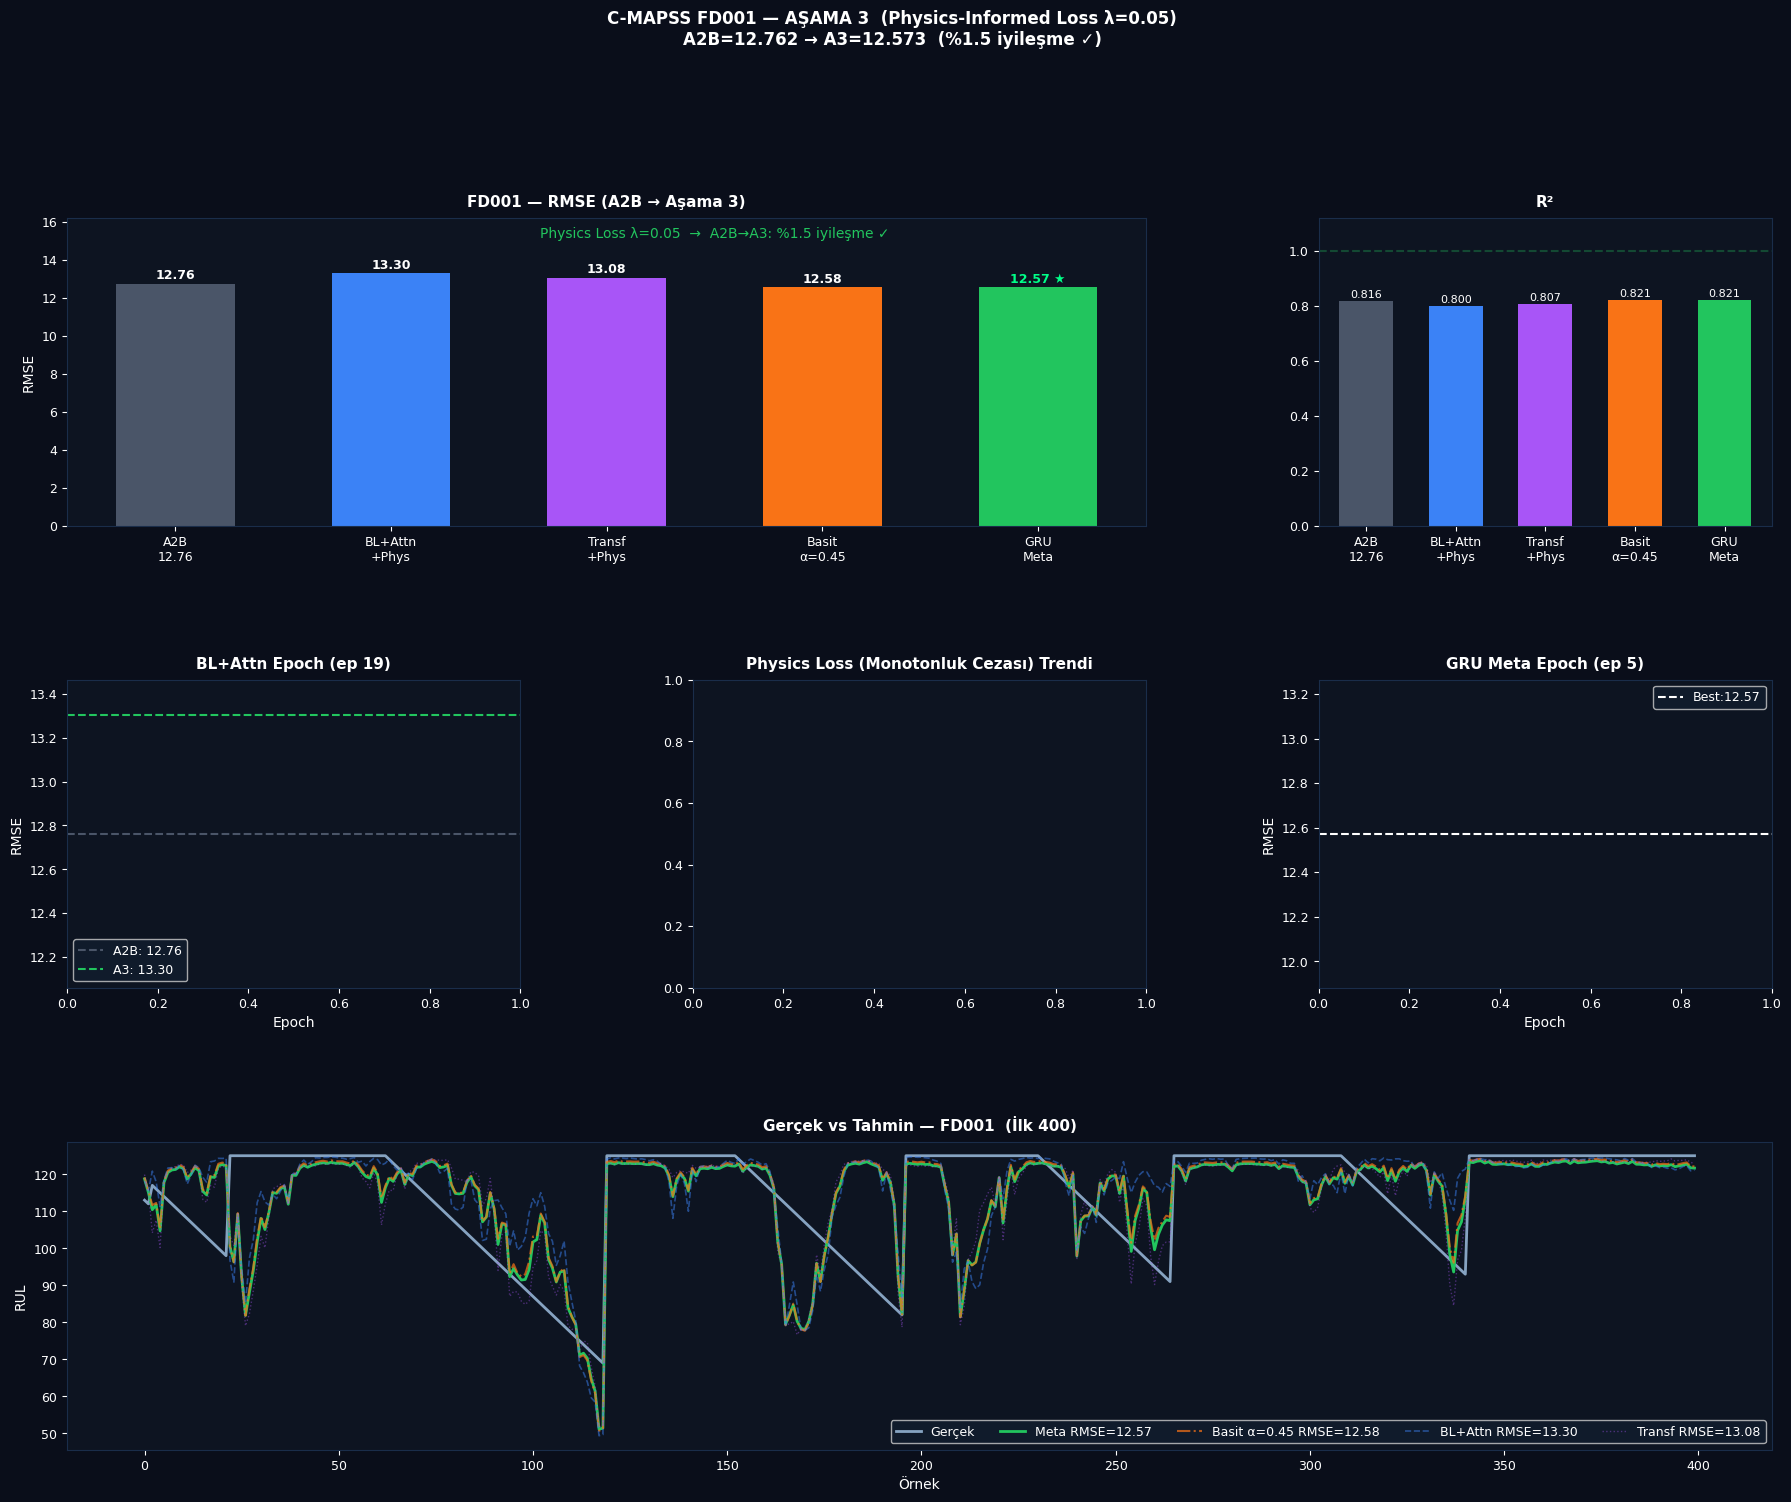

  ✓ Grafik: /content/drive/MyDrive/cmapss_asama3/FD001/asama3_FD001.png

#################################################################
#  FD001 TAMAMLANDI
#################################################################

#################################################################
#  AŞAMA 3 — FD002  (Physics Loss λ=0.05)
#################################################################
  [FD002] Train: (46219, 30, 23) | Test: (26505, 30, 23)

[ADIM 1] BiLSTM+Attention (Physics Loss)...

  [BL+Attn[FD002]] Checkpoint → yükleniyor
  ✓ bilstm_attn_FD002: RMSE=15.826  R²=0.7392

[ADIM 2] Transformer (Physics Loss)...

  [Transformer[FD002]] Checkpoint → yükleniyor
  ✓ transformer_FD002: RMSE=15.752  R²=0.7417

[ADIM 3] OOF tahminleri (Physics Loss)...

  [BL+Attn] OOF cache → yükleniyor
  OOF RMSE: 15.703

  [Transformer] OOF cache → yükleniyor
  OOF RMSE: 16.709

[ADIM 4] GRU Meta...

  [Meta] Checkpoint → yükleniyor
  ✓ meta_FD002: RMSE=15.401  R²=0.7531
  Meta: RMSE=15.401

 

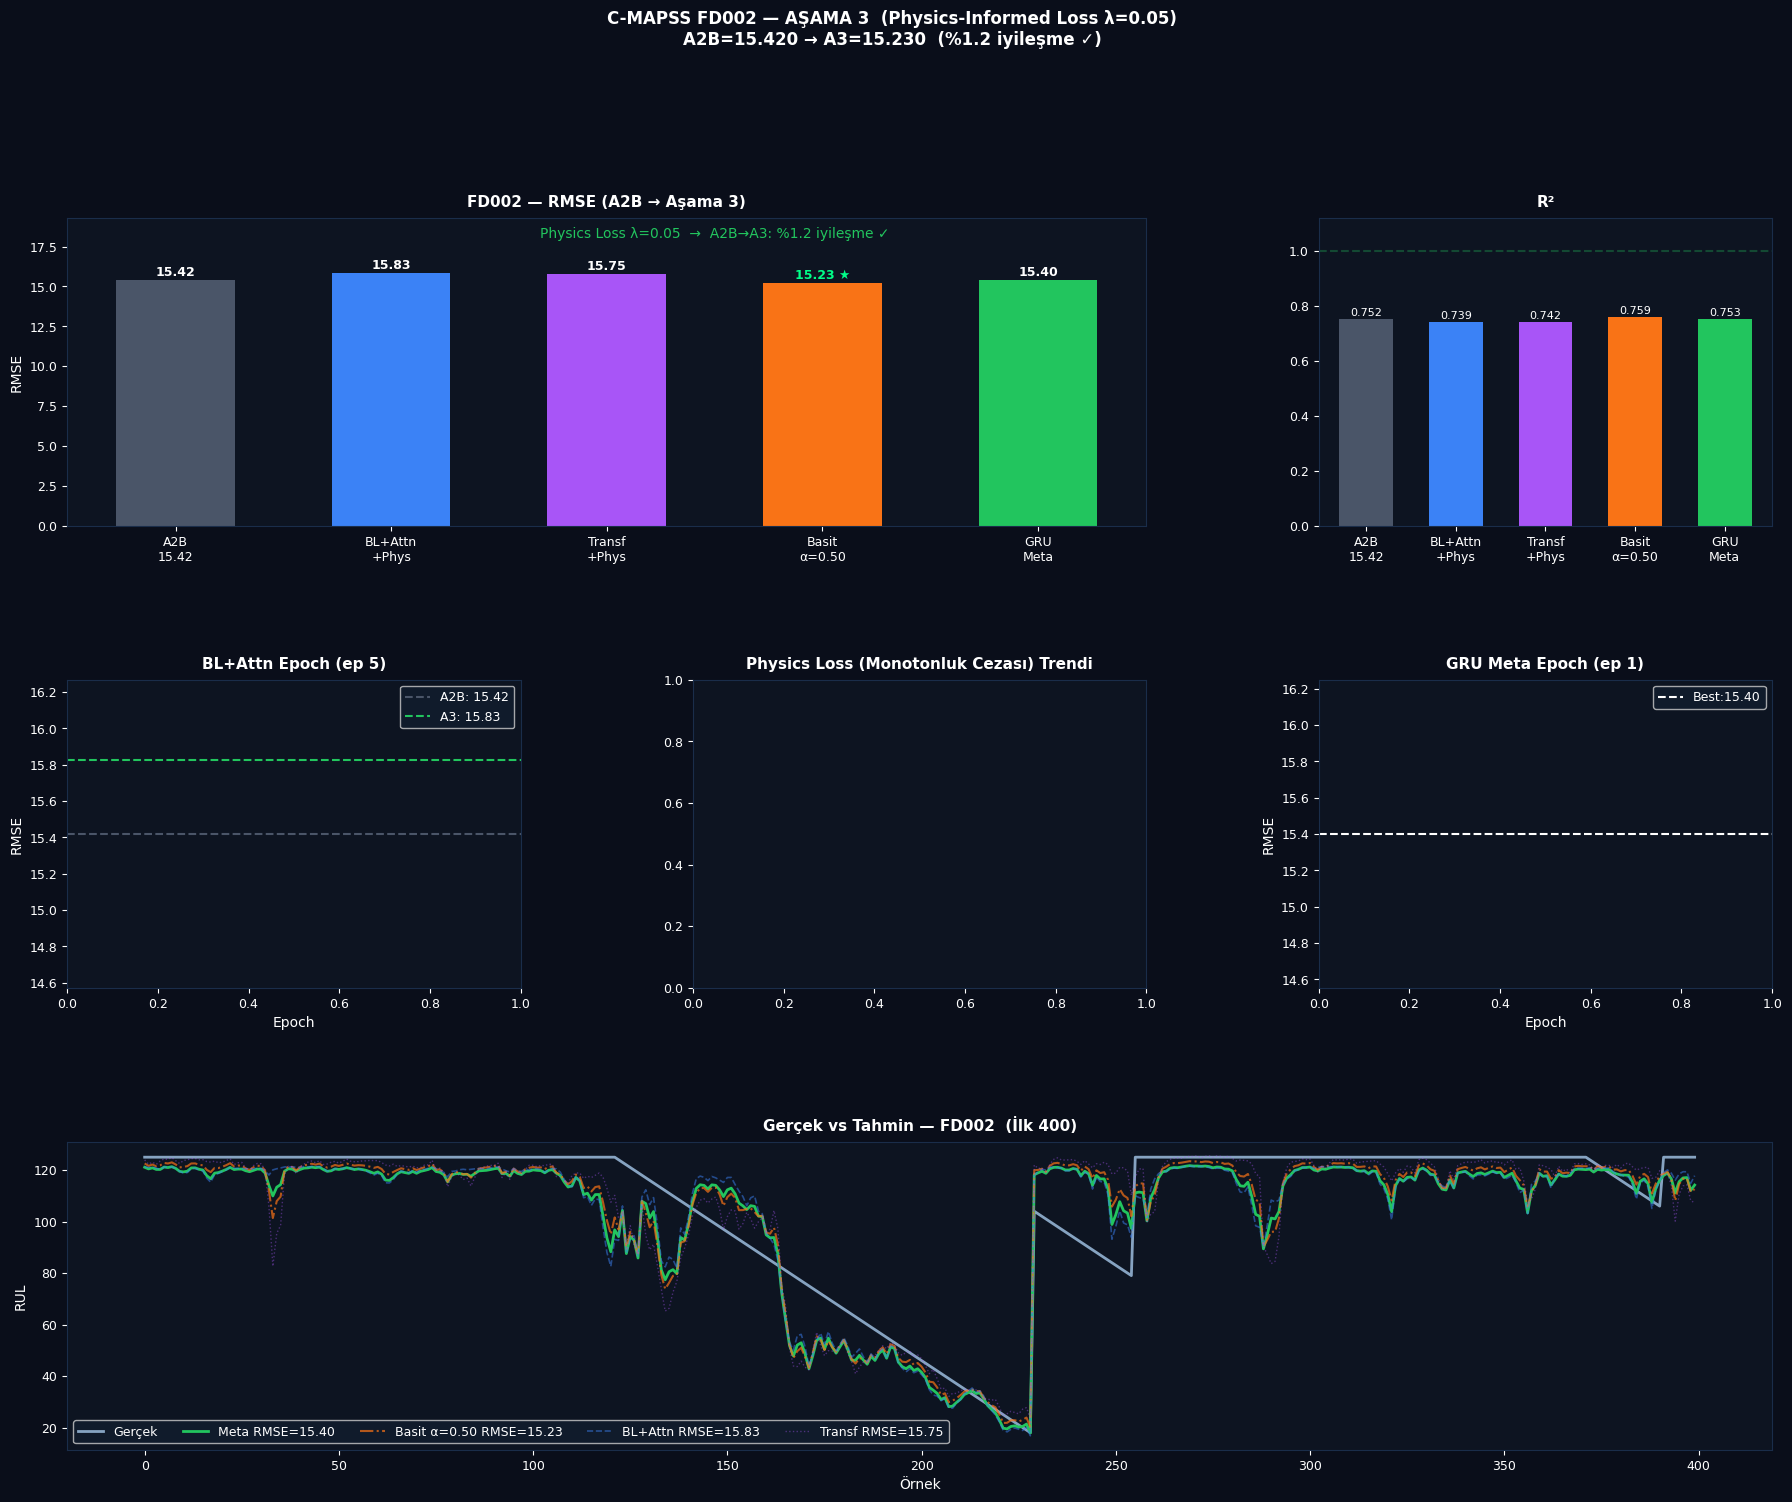

  ✓ Grafik: /content/drive/MyDrive/cmapss_asama3/FD002/asama3_FD002.png

#################################################################
#  FD002 TAMAMLANDI
#################################################################

#################################################################
#  AŞAMA 3 — FD003  (Physics Loss λ=0.02)
#################################################################
  [FD003] Train: (21820, 30, 16) | Test: (13696, 30, 16)

[ADIM 1] BiLSTM+Attention (Physics Loss)...

  [BL+Attn[FD003]] Checkpoint → yükleniyor
  ✓ bilstm_attn_FD003: RMSE=10.897  R²=0.8320

[ADIM 2] Transformer (Physics Loss)...

  [Transformer[FD003]] Checkpoint → yükleniyor
  ✓ transformer_FD003: RMSE=10.758  R²=0.8363

[ADIM 3] OOF tahminleri (Physics Loss)...

  [BL+Attn] OOF cache → yükleniyor
  OOF RMSE: 11.566

  [Transformer] OOF cache → yükleniyor
  OOF RMSE: 11.532

[ADIM 4] GRU Meta...

  [Meta] Checkpoint → yükleniyor
  ✓ meta_FD003: RMSE=10.442  R²=0.8457
  Meta: RMSE=10.442

 

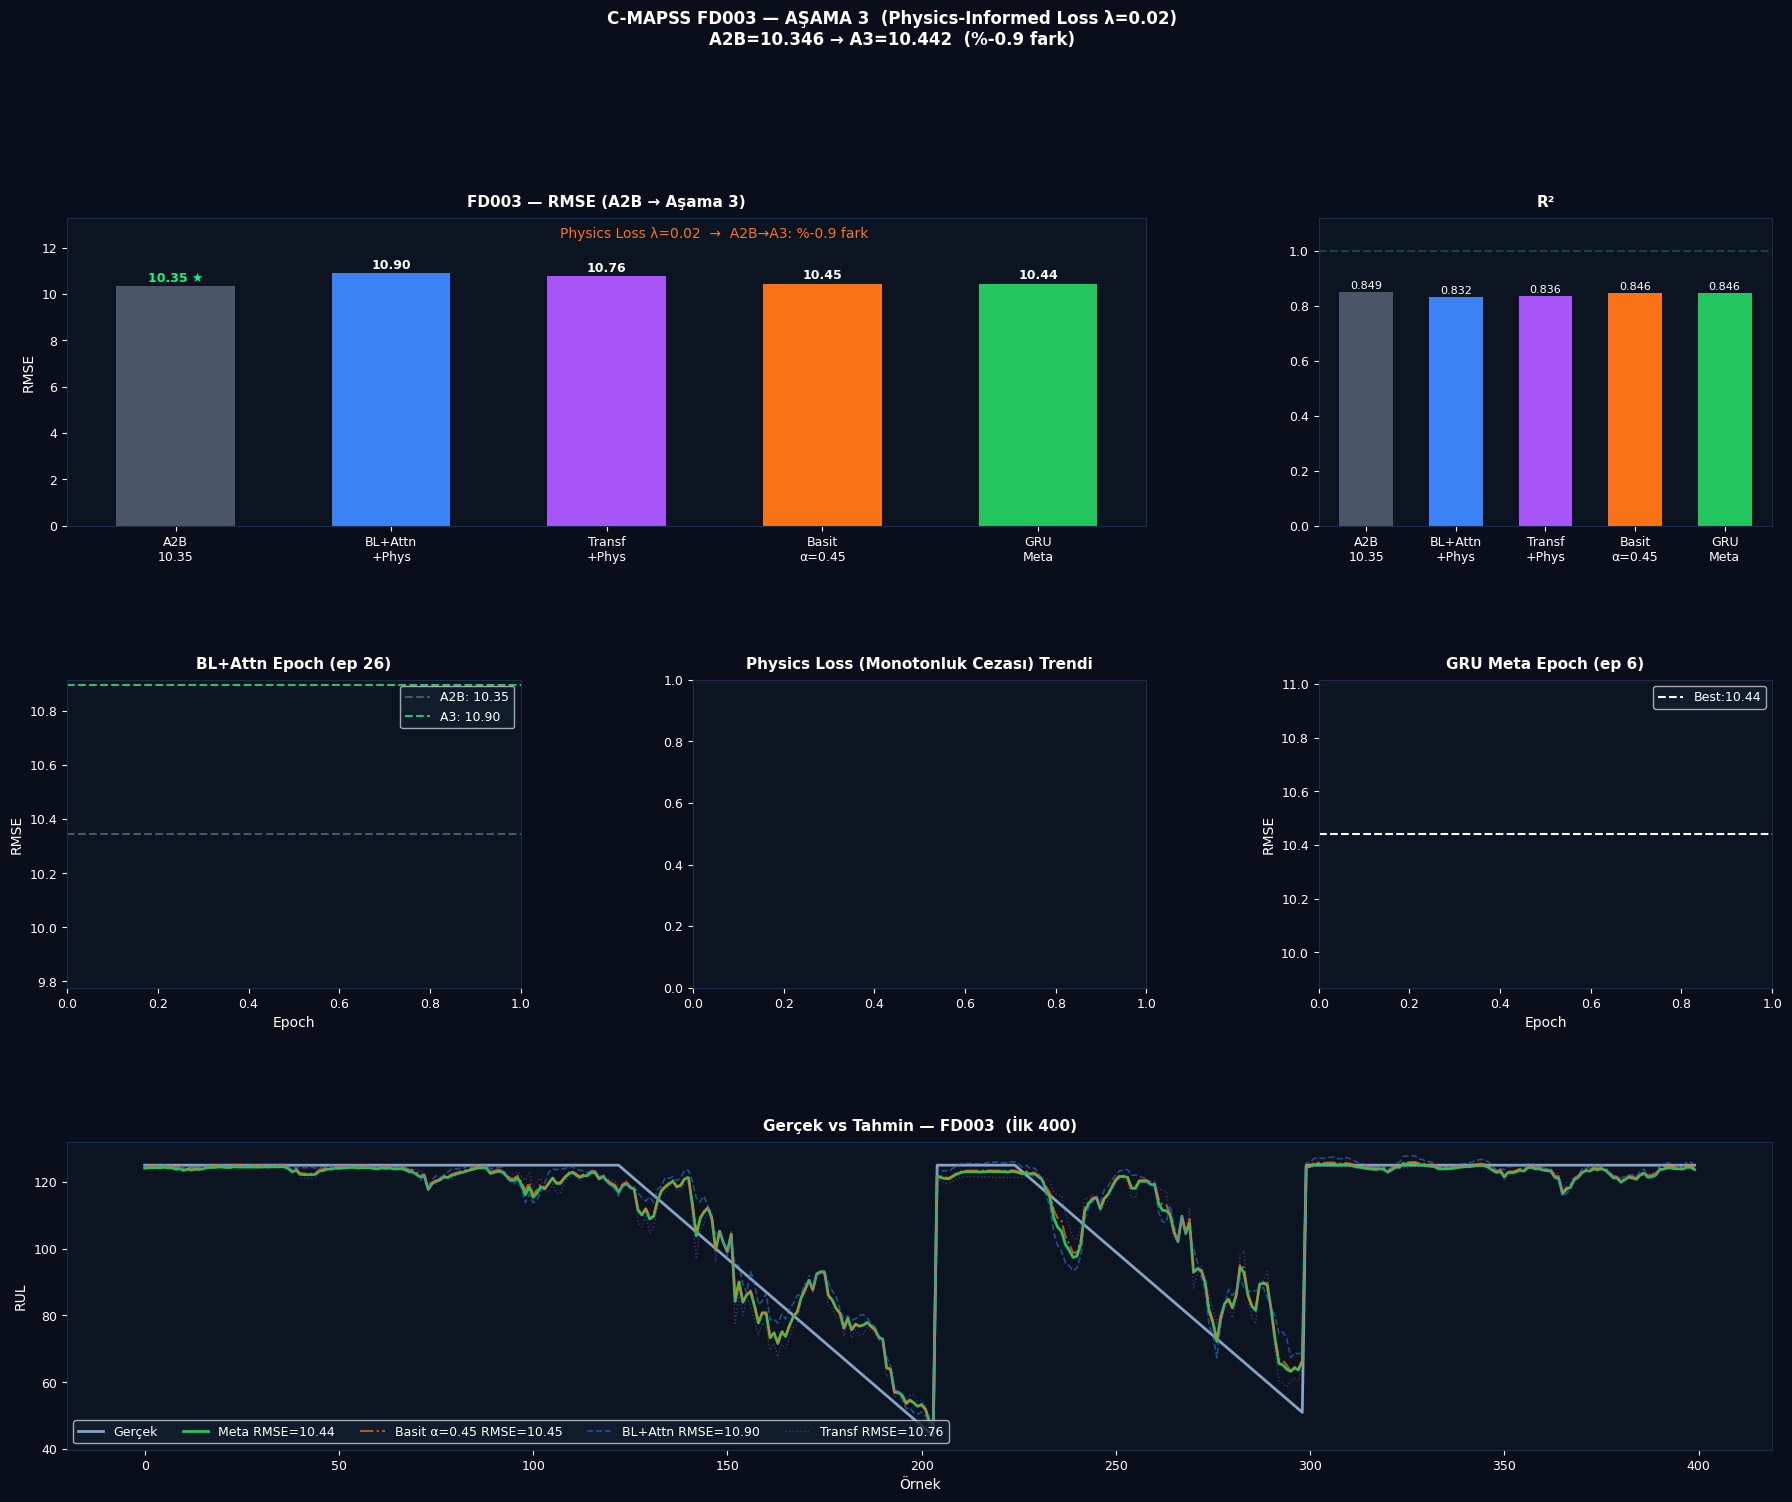

  ✓ Grafik: /content/drive/MyDrive/cmapss_asama3/FD003/asama3_FD003.png

#################################################################
#  FD003 TAMAMLANDI
#################################################################

#################################################################
#  AŞAMA 3 — FD004  (Physics Loss λ=0.02)
#################################################################
  [FD004] Train: (54028, 30, 23) | Test: (34081, 30, 23)

[ADIM 1] BiLSTM+Attention (Physics Loss)...

  [BL+Attn[FD004]] Checkpoint → yükleniyor
  ✓ bilstm_attn_FD004: RMSE=14.611  R²=0.7138

[ADIM 2] Transformer (Physics Loss)...

  [Transformer[FD004]] Checkpoint → yükleniyor
  ✓ transformer_FD004: RMSE=14.632  R²=0.7130

[ADIM 3] OOF tahminleri (Physics Loss)...

  [BL+Attn] OOF cache → yükleniyor
  OOF RMSE: 15.264

  [Transformer] OOF cache → yükleniyor
  OOF RMSE: 15.926

[ADIM 4] GRU Meta...

  [Meta] Checkpoint → yükleniyor
  ✓ meta_FD004: RMSE=14.024  R²=0.7364
  Meta: RMSE=14.024

 

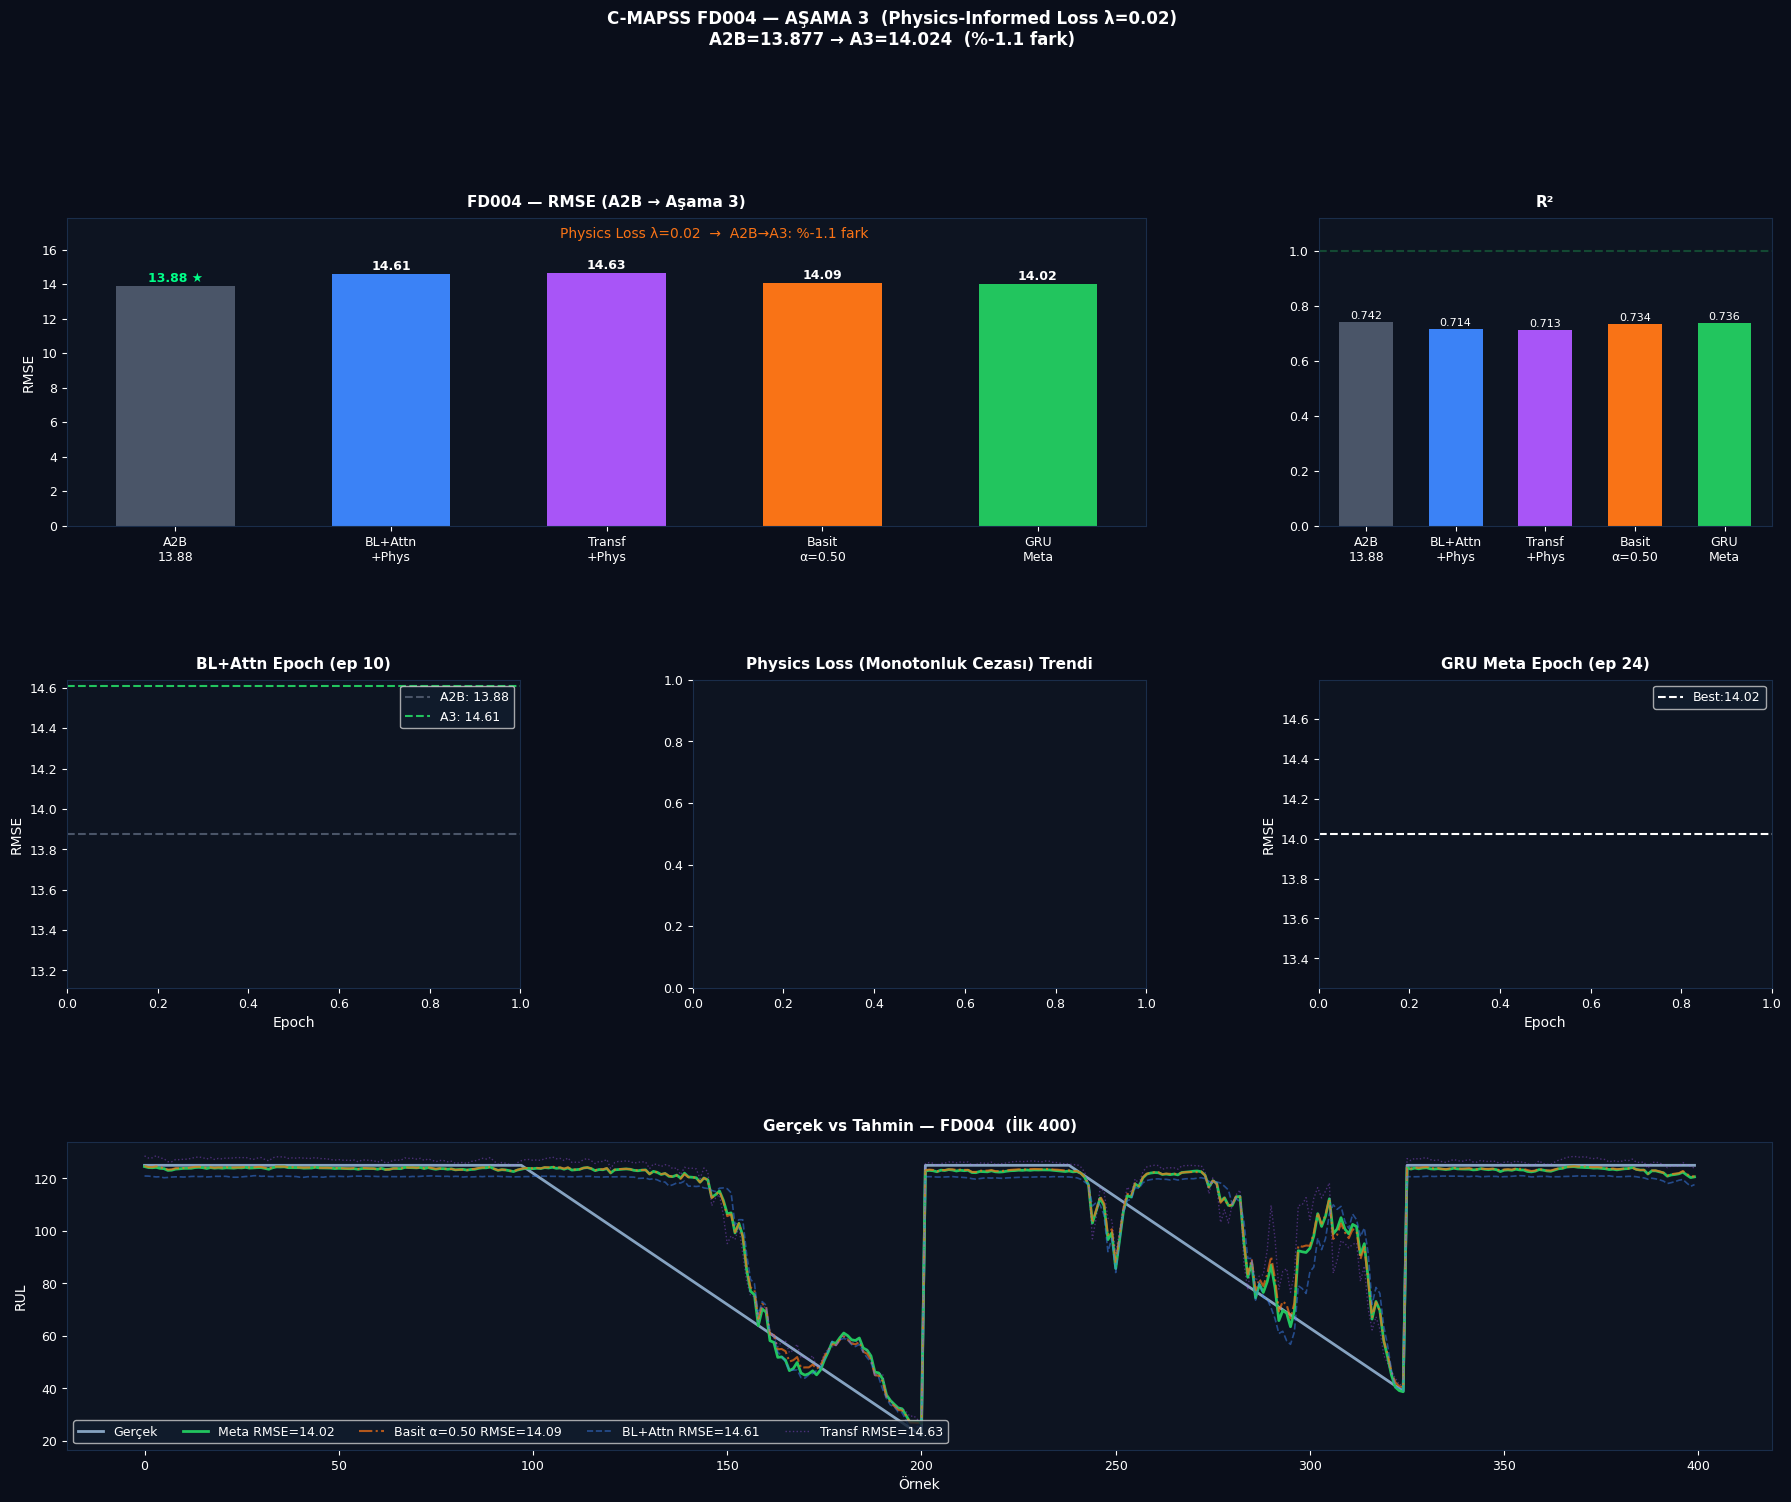

  ✓ Grafik: /content/drive/MyDrive/cmapss_asama3/FD004/asama3_FD004.png

#################################################################
#  FD004 TAMAMLANDI
#################################################################


In [13]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 11 — Ana Pipeline                        ║
# ╚══════════════════════════════════════════════════╝

# λ (lambda) değeri — monotonluk cezası ağırlığı
# 0.05 → hafif, önerilen başlangıç
# 0.10 → güçlü
# Subset bazında lambda — her subset için ayrı ayar
LAMBDA_PHYS_MAP = {
    'FD001': 0.05,   # ← zaten iyi, dokunma
    'FD002': 0.05,   # ← zaten iyi, dokunma
    'FD003': 0.02,   # ← 0.05 fazla güçlüydü, hafiflet
    'FD004': 0.02,   # ← 0.05 fazla güçlüydü, hafiflet
}

all_results = []

for SUBSET in ['FD001', 'FD002', 'FD003', 'FD004']:

    LAMBDA_PHYS = LAMBDA_PHYS_MAP[SUBSET]
    print(f"\n{'#'*65}")
    print(f"#  AŞAMA 3 — {SUBSET}  (Physics Loss λ={LAMBDA_PHYS})")
    print(f"{'#'*65}")

    data = load_and_prepare(SUBSET)
    N    = data['n_feat']

    A3_CKPT  = os.path.join(A3_CKPT_ROOT, SUBSET)
    SAVE_DIR = os.path.join(SAVE_ROOT, SUBSET)
    os.makedirs(A3_CKPT, exist_ok=True); os.makedirs(SAVE_DIR, exist_ok=True)

    # ADIM 1 — BiLSTM+Attention (Physics Loss ile sıfırdan)
    print(f"\n[ADIM 1] BiLSTM+Attention (Physics Loss)...")
    bl_m, bl_p, bl_mdl = train_base(
        BiLSTMAttention(N), data,
        max_ep=200, lr=1e-3, patience=15,
        name=f'BL+Attn[{SUBSET}]',
        ck_name='bilstm_attn', ck_dir=A3_CKPT,
        force=False, lambda_phys=LAMBDA_PHYS
    )

    # ADIM 2 — Transformer (Physics Loss ile sıfırdan)
    print(f"\n[ADIM 2] Transformer (Physics Loss)...")
    tf_m, tf_p, tf_mdl = train_base(
        TransformerRUL(N), data,
        max_ep=200, lr=5e-4, patience=15,
        name=f'Transformer[{SUBSET}]',
        ck_name='transformer', ck_dir=A3_CKPT,
        force=False, lambda_phys=LAMBDA_PHYS
    )

    # ADIM 3 — OOF (Physics Loss ile)
    print(f"\n[ADIM 3] OOF tahminleri (Physics Loss)...")
    oof_bl = get_oof(
        BiLSTMAttention, {'n_feat': N}, data,
        n_splits=5, max_ep=150, lr=1e-3, patience=15,
        name='BL+Attn', ck_name='bilstm_attn',
        ck_dir=A3_CKPT, force=False, lambda_phys=LAMBDA_PHYS
    )
    oof_tf = get_oof(
        TransformerRUL, {'n_feat': N}, data,
        n_splits=5, max_ep=150, lr=5e-4, patience=15,
        name='Transformer', ck_name='transformer',
        ck_dir=A3_CKPT, force=False, lambda_phys=LAMBDA_PHYS
    )

    # ADIM 4 — GRU Meta
    print(f"\n[ADIM 4] GRU Meta...")
    meta_m, meta_p = train_meta(
        GRUMetaModel(N), data, oof_bl, oof_tf, bl_p, tf_p,
        max_ep=100, lr=5e-4, patience=20,
        ck_name='meta', ck_dir=A3_CKPT,
        force=False, lambda_phys=LAMBDA_PHYS
    )

    # Basit Ensemble
    best_a, best_r = 0.5, float('inf')
    for a in np.arange(0, 1.01, 0.05):
        r = float(np.sqrt(mean_squared_error(
            data['y_te'], a*bl_p+(1-a)*tf_p)))
        if r < best_r: best_r=r; best_a=a
    si_p = best_a*bl_p + (1-best_a)*tf_p
    si_m = get_metrics(data['y_te'], si_p)

    # Özet
    best_new = min(bl_m['RMSE'], tf_m['RMSE'], si_m['RMSE'], meta_m['RMSE'])
    a2b_best = A2B_BEST.get(SUBSET,{}).get('best_rmse')
    iy_2b    = ((a2b_best-best_new)/a2b_best*100) if a2b_best else 0

    print(f"\n{'='*72}")
    print(f"  {SUBSET} — AŞAMA 3 ÖZET (λ={LAMBDA_PHYS})")
    print(f"{'='*72}")
    if a2b_best:
        print(f"  {'Aşama 2B en iyi':<38} {a2b_best:>7.3f}  "
              f"({A2B_BEST[SUBSET]['model']})")
    print(f"  {'─'*65}")
    print(f"  {'Model':<38} {'RMSE':>7} {'R²':>8} {'Score':>12} {'Ep':>6}")
    print(f"  {'─'*65}")
    for lbl, m in [
        ('BiLSTM+Attn (Physics Loss)',   bl_m),
        ('Transformer (Physics Loss)',   tf_m),
        (f'Basit Ens α={best_a:.2f}',    si_m),
        ('GRU Meta ★',                   meta_m),
    ]:
        ep = str(m.get('best_ep','—'))
        mk = " ← EN İYİ" if abs(m['RMSE']-best_new)<0.001 else ""
        print(f"  {lbl:<38} {m['RMSE']:>7.3f} {m['R2']:>8.4f} "
              f"{m['Score']:>12.1f} {ep:>6}{mk}")
    if a2b_best:
        print(f"\n  A2B→A3: {a2b_best:.3f}→{best_new:.3f}  "
              f"(%{iy_2b:.1f} {'iyileşme ✓' if iy_2b>0 else 'fark — lambda düşürmeyi dene'})")

    plot_results(SUBSET, data, bl_m, tf_m, si_m, meta_m,
                 bl_p, tf_p, si_p, meta_p, best_a, SAVE_DIR, LAMBDA_PHYS)

    # CSV
    rows = []
    if a2b_best:
        rows.append({'Subset':SUBSET,'Model':f'A2B en iyi ({A2B_BEST[SUBSET]["model"]})',
                     'Tip':'A2B_ref','RMSE':a2b_best,'R2':A2B_BEST[SUBSET]['best_r2'],
                     'Score':'—','Best_Ep':'—','Lambda':'—'})
    for lbl, m in [('BL+Attn_Physics',bl_m),('Transformer_Physics',tf_m),
                    (f'Basit_a={best_a}',si_m),('GRU_Meta',meta_m)]:
        rows.append({'Subset':SUBSET,'Model':lbl,'Tip':'Asama3',
                     'RMSE':round(m['RMSE'],4),'R2':round(m['R2'],4),
                     'Score':round(m['Score'],1),'Best_Ep':m.get('best_ep','—'),
                     'Lambda':LAMBDA_PHYS})
    pd.DataFrame(rows).to_csv(
        os.path.join(SAVE_DIR,f'asama3_{SUBSET}.csv'), index=False)

    all_results.append({
        'Subset':SUBSET,'A2B_best':a2b_best,
        'BL_Attn':round(bl_m['RMSE'],3),'Transformer':round(tf_m['RMSE'],3),
        'Simple':round(si_m['RMSE'],3),'Meta':round(meta_m['RMSE'],3),
        'Best_A3':round(best_new,3),'Iy_A2B':round(iy_2b,1),
        'Lambda':LAMBDA_PHYS,
    })

    del bl_mdl, tf_mdl; torch.cuda.empty_cache()
    print(f"\n{'#'*65}\n#  {SUBSET} TAMAMLANDI\n{'#'*65}")

In [14]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 12 — Genel Özet                          ║
# ╚══════════════════════════════════════════════════╝

df = pd.DataFrame(all_results)
print(f"\n{'='*80}")
print(f"  AŞAMA 3 — TÜM SUBSETLER ÖZET (Physics Loss λ={LAMBDA_PHYS})")
print(f"{'='*80}")
print(f"  {'Sub':<6} {'A2B':>7} {'BL+P':>8} {'TF+P':>8} "
      f"{'Basit':>8} {'Meta':>8} {'A3 EN İYİ':>10} {'A2B→A3':>8}")
print(f"  {'─'*72}")
for _, r in df.iterrows():
    best = r['Best_A3']
    bl = f"{r['BL_Attn']:.3f}"   +(' ★' if r['BL_Attn']   ==best else '')
    tf = f"{r['Transformer']:.3f}"+(' ★' if r['Transformer']==best else '')
    si = f"{r['Simple']:.3f}"    +(' ★' if r['Simple']     ==best else '')
    me = f"{r['Meta']:.3f}"      +(' ★' if r['Meta']       ==best else '')
    a2 = f"{r['A2B_best']:.3f}" if r['A2B_best'] else '—'
    iy = f"%{r['Iy_A2B']:.1f}"  +(' ✓' if r['Iy_A2B']>0 else '')
    print(f"  {r['Subset']:<6} {a2:>7} {bl:>8} {tf:>8} "
          f"{si:>8} {me:>8} {best:>10.3f} {iy:>8}")

df.to_csv(f'{SAVE_ROOT}/asama3_ozet.csv', index=False)

# A1 → A2B → A3 karşılaştırma
A1_BEST = {
    'FD001':13.104,'FD002':16.696,'FD003':10.431,'FD004':16.239}
print(f"\n  {'Sub':<6} {'A1':>7} {'A2B':>7} {'A3':>7} {'Toplam İy.':>12}")
print(f"  {'─'*40}")
for _, r in df.iterrows():
    s = r['Subset']
    a1 = A1_BEST.get(s)
    a3 = r['Best_A3']
    total_iy = ((a1-a3)/a1*100) if a1 else 0
    print(f"  {s:<6} {a1:>7.3f} {r['A2B_best']:>7.3f} "
          f"{a3:>7.3f} %{total_iy:>9.1f} ✓")

print(f"\n✓ Özet: {SAVE_ROOT}/asama3_ozet.csv")
print(f"\n{'='*65}")
print(f"  AŞAMA 3 TAMAMLANDI")
print(f"  ─────────────────────────────────────────────")
print(f"  Eğer λ={LAMBDA_PHYS} fark yaratmadıysa:")
print(f"    LAMBDA_PHYS = 0.10 ile tekrar dene")
print(f"  Sıradaki: Final Pipeline — tüm aşamaları birleştir")
print(f"{'='*65}")


  AŞAMA 3 — TÜM SUBSETLER ÖZET (Physics Loss λ=0.02)
  Sub        A2B     BL+P     TF+P    Basit     Meta  A3 EN İYİ   A2B→A3
  ────────────────────────────────────────────────────────────────────────
  FD001   12.762   13.303   13.076   12.576 12.573 ★     12.573   %1.5 ✓
  FD002   15.420   15.826   15.752 15.230 ★   15.401     15.230   %1.2 ✓
  FD003   10.346   10.897   10.758   10.447 10.442 ★     10.442    %-0.9
  FD004   13.877   14.611   14.632   14.089 14.024 ★     14.024    %-1.1

  Sub         A1     A2B      A3   Toplam İy.
  ────────────────────────────────────────
  FD001   13.104  12.762  12.573 %      4.1 ✓
  FD002   16.696  15.420  15.230 %      8.8 ✓
  FD003   10.431  10.346  10.442 %     -0.1 ✓
  FD004   16.239  13.877  14.024 %     13.6 ✓

✓ Özet: /content/drive/MyDrive/cmapss_asama3/asama3_ozet.csv

  AŞAMA 3 TAMAMLANDI
  ─────────────────────────────────────────────
  Eğer λ=0.02 fark yaratmadıysa:
    LAMBDA_PHYS = 0.10 ile tekrar dene
  Sıradaki: Final Pipeline —


NASA Score Karşılaştırması — FD001


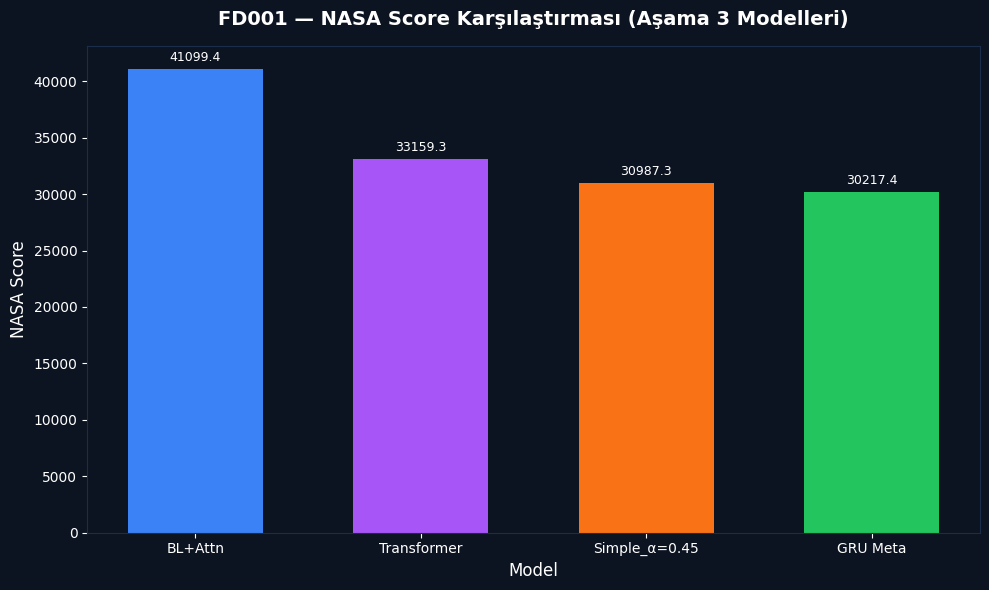


------------------------------------------------------------
FD001 — Aşama 3 Modelleri NASA Score Özeti:
/content/drive/MyDrive/cmapss_asama3/FD001/asama3_FD001.csv

------------------------------------------------------------
BL+Attn                        : 41099.4
Transformer                    : 33159.3
Simple_α=0.45                  : 30987.3
GRU Meta                       : 30217.4

NASA Score Karşılaştırması — FD002


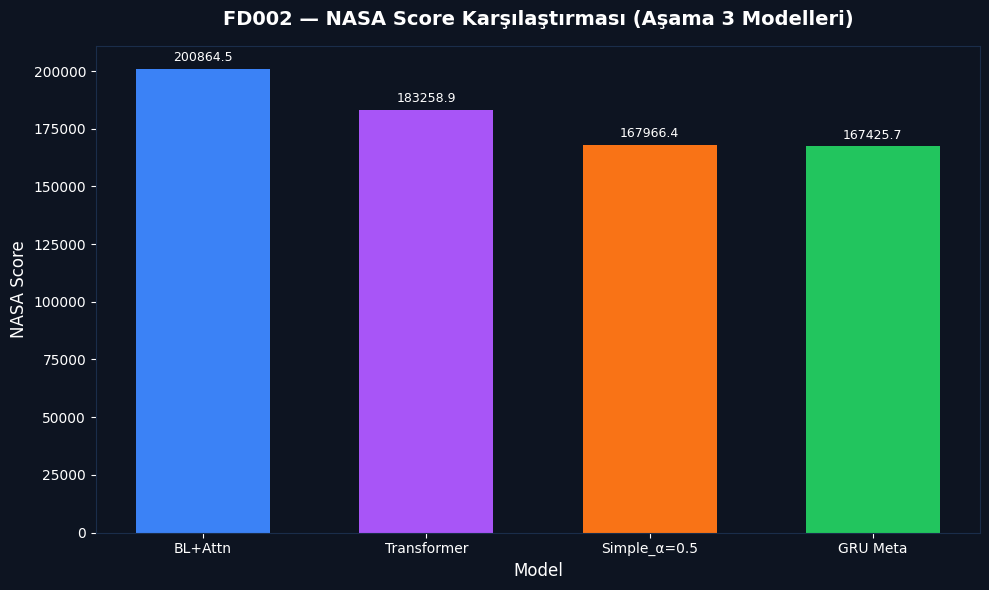


------------------------------------------------------------
FD002 — Aşama 3 Modelleri NASA Score Özeti:
/content/drive/MyDrive/cmapss_asama3/FD002/asama3_FD002.csv

------------------------------------------------------------
BL+Attn                        : 200864.5
Transformer                    : 183258.9
Simple_α=0.5                   : 167966.4
GRU Meta                       : 167425.7

NASA Score Karşılaştırması — FD003


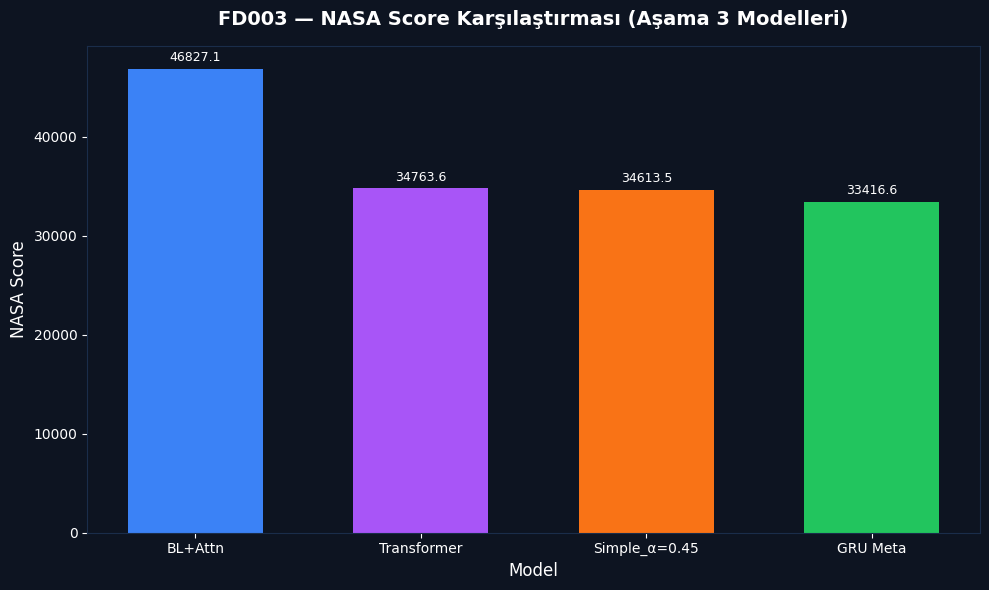


------------------------------------------------------------
FD003 — Aşama 3 Modelleri NASA Score Özeti:
/content/drive/MyDrive/cmapss_asama3/FD003/asama3_FD003.csv

------------------------------------------------------------
BL+Attn                        : 46827.1
Transformer                    : 34763.6
Simple_α=0.45                  : 34613.5
GRU Meta                       : 33416.6

NASA Score Karşılaştırması — FD004


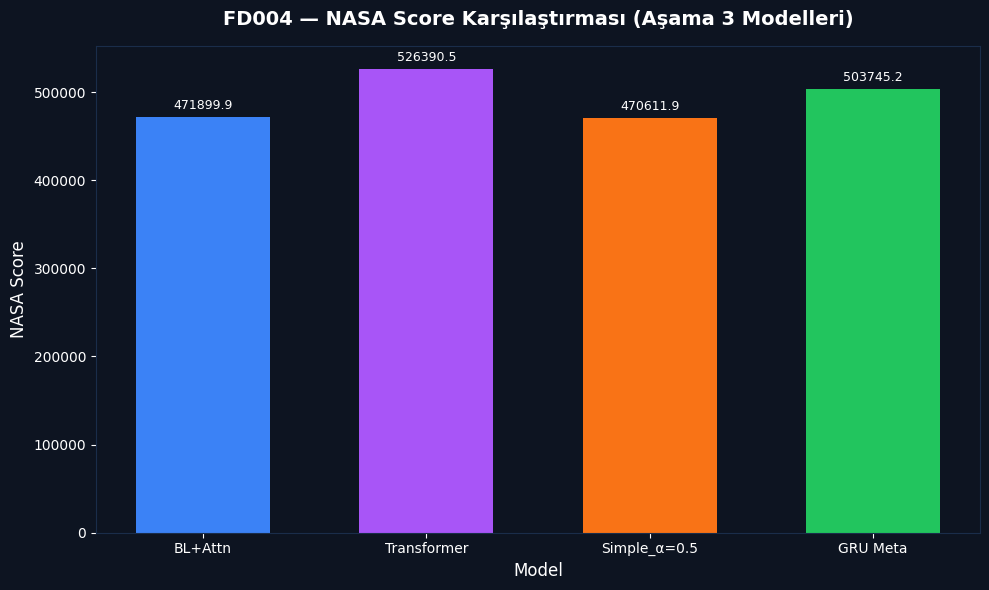


------------------------------------------------------------
FD004 — Aşama 3 Modelleri NASA Score Özeti:
/content/drive/MyDrive/cmapss_asama3/FD004/asama3_FD004.csv

------------------------------------------------------------
BL+Attn                        : 471899.9
Transformer                    : 526390.5
Simple_α=0.5                   : 470611.9
GRU Meta                       : 503745.2


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import os

ALL_SUBSETS = ['FD001', 'FD002', 'FD003', 'FD004']
SAVE_ROOT = '/content/drive/MyDrive/cmapss_asama3'

# Define colors for consistency with previous plots
C_BL='#3b82f6'
C_TF='#a855f7'
C_SI='#f97316'
C_ME='#22c55e'
BG='#0d1421'; TXT='white'

for SUBSET in ALL_SUBSETS:
    print(f"\n{'='*70}")
    print(f"NASA Score Karşılaştırması — {SUBSET}")
    print(f"{'='*70}")

    csv_path = os.path.join(SAVE_ROOT, SUBSET, f'asama3_{SUBSET}.csv')

    # Check if the CSV file exists
    if not os.path.exists(csv_path):
        print(f"Uyarı: {csv_path} bulunamadı. Bu altküme için sonuçlar atlanıyor.")
        continue

    df_subset = pd.read_csv(csv_path)

    # Prepare data for plotting NASA scores from Aşama 3 models
    model_names = []
    nasa_scores = []
    colors = []

    # Iterate over models in Aşama 3
    for index, row in df_subset[df_subset['Tip'] == 'Asama3'].iterrows():
        # Clean up model names for better readability on the plot
        display_name = row['Model'].replace('_Physics', '').replace('Basit_a=', 'Simple_α=').replace('GRU_Meta', 'GRU Meta')
        model_names.append(display_name)
        # Convert score to float before appending
        nasa_scores.append(float(row['Score']))

        # Assign colors based on model type
        if 'BL+Attn' in display_name: colors.append(C_BL)
        elif 'Transformer' in display_name: colors.append(C_TF)
        elif 'Simple' in display_name: colors.append(C_SI)
        elif 'GRU Meta' in display_name: colors.append(C_ME)
        else: colors.append('gray') # Fallback for any other model type

    # Plotting NASA Scores
    fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
    ax.set_facecolor(BG)
    ax.set_title(f'{SUBSET} — NASA Score Karşılaştırması (Aşama 3 Modelleri)', color=TXT, fontsize=14, fontweight='bold', pad=15)
    ax.tick_params(colors=TXT, labelsize=10)
    for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

    bars = ax.bar(model_names, nasa_scores, color=colors, edgecolor='none', width=0.6)

    # Add value labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + (max(nasa_scores)*0.01), # Offset label slightly above bar
                f'{yval:.1f}', ha='center', va='bottom', color=TXT, fontsize=9)

    ax.set_ylabel('NASA Score', color=TXT, fontsize=12)
    ax.set_xlabel('Model', color=TXT, fontsize=12)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Also, provide the numerical summary for the current SUBSET
    print(f"\n{'-'*60}")
    print(f"{SUBSET} — Aşama 3 Modelleri NASA Score Özeti:")
    print(f"{(SAVE_ROOT)}/{SUBSET}/asama3_{SUBSET}.csv")
    print(f"\n{'-'*60}")
    for index, row in df_subset[df_subset['Tip'] == 'Asama3'].iterrows():
        display_name = row['Model'].replace('_Physics', '').replace('Basit_a=', 'Simple_α=').replace('GRU_Meta', 'GRU Meta')
        print(f"{display_name:<30} : {float(row['Score']):.1f}")